# Exploratory Data Analysis: ECHR Violation Prediction

## 1. Hypothesis and Research Question
**Goal:** Define a clear objective.
* **Primary Question:** Can we predict whether a human rights violation occurred based purely on the text of the "FACTS" section of an ECHR (European Court of Human Rights) case?
* **Secondary Questions (Bias/Fairness):** Are there observable biases in case outcomes based on the Respondent State (country) or temporal factors (year)? Does legal representation affect the outcome?

This notebook aims to explore the ECHR dataset to understand its characteristics, distribution, and potential biases before building classification models.

## 2. Data Applicability
**Goal:** Justify the dataset choice.
The ECHR dataset is an excellent candidate for this research question because it contains highly structured legal judgements. The dataset provides the "FACTS" of the case (written before the judgement is passed), making it ideal for predictive text classification. It provides clear binary labels ("Violation" vs "Non-Violation") and rich metadata (Respondent State, Date, Legal Representation), allowing for robust Distributional NLP analysis.

## 3. Ethical Data Collection Standards
**Goal:** Address ethical concerns.
The dataset is acquired from the official HUDOC database via public APIs. While public, using legal data involves ethical considerations. Models trained on historical legal texts can inadvertently learn and perpetuate systemic biases (e.g., bias against certain nations or demographics). This EDA explicitly explores such potential biases (metadata correlation with outcomes) to ensure we are not creating an unfairly biased "black box" model.


In [4]:
%matplotlib inline
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

# Advanced NLP Libraries
import nltk
from nltk.text import Text
from nltk.tokenize import word_tokenize
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt')
    
import scattertext as st
import shifterator as sh

# Patch shifterator for Python 3.10+ compatibility
import collections
if not hasattr(collections, 'Mapping'):
    import collections.abc
    collections.Mapping = collections.abc.Mapping

# Configure plotting
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

## 4. Inventiveness in Data Preparation
**Goal:** Show creativity in data preparation.

Instead of just loading the pre-processed texts, we will:
1. Merge the processed text data (which cleanly extracts the `FACTS` section) with the raw metadata.
2. **Inventive Feature Extraction using Regex:** We'll use Regular Expressions on the `representedby` or `text` fields to engineer a new feature: `has_representation`, assessing if having a lawyer correlates with winning the case.
3. Extract the year from the `judgementdate` to observe temporal trends.

In [5]:
# 1. Load Processed Text (FACTS section) - We use train.csv for EDA to prevent data leakage from a test set
df_text = pd.read_csv('data/processed/train.csv')

# 2. Load Metadata
df_meta = pd.read_csv('data/raw/metadata.csv')

# 3. Merge based on item_id
df = pd.merge(df_text, df_meta, left_on='item_id', right_on='itemid', how='inner')

# 4. Feature Engineering
# Extract Year
df['year'] = pd.to_datetime(df['judgementdate']).dt.year

# Inventive Feature: Representation Status using Regex
# We check if 'representedby' is not null, or we could regex the text
def has_lawyer(val):
    if pd.isna(val):
        return False
    val = str(val).lower()
    # If the representation field says 'none', 'self' etc., it might mean no lawyer
    # We use regex to find if it actually contains a lawyer's name or law firm
    if re.search(r'\b(none|n/a)\b', val):
        return False
    return len(val.strip()) > 3

df['has_representation'] = df['representedby'].apply(has_lawyer)

# Clean up label names for plotting
df['label_name'] = df['label'].map({1: 'Violation', 0: 'Non-Violation'})

print(f"Dataset loaded with {len(df)} records and {len(df.columns)} features.")
df[['item_id', 'respondent', 'year', 'has_representation', 'label_name']].head()

Dataset loaded with 627 records and 33 features.


/tmp/ipykernel_331110/3599674414.py:12: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['year'] = pd.to_datetime(df['judgementdate']).dt.year


,item_id,respondent,year,has_representation,label_name
0,001-103117,BGR,2011,True,Violation
1,001-101208,RUS,2010,False,Violation
2,001-101191,RUS,2010,False,Violation
3,001-101019,POL,2010,True,Violation
4,001-140402,MKD,2014,True,Non-Violation


## 5. Description of Data & Descriptive Stats
**Goal:** Explore variables, data points, stats, and cautions.

Here we analyze the distribution of classes, the average length of the text feature, and check for missing values.

In [4]:
# Class Balance
print("=== Class Distribution ===")
print(df['label_name'].value_counts(normalize=True) * 100)
print("\n")

# Text Length Analysis
df['text_length'] = df['text'].astype(str).apply(lambda x: len(x.split()))
print("=== Text Length (Word Count) Statistics ===")
print(df['text_length'].describe())
print("\n")

# Missing values
print("=== Missing Data in Key Columns ===")
print(df[['text', 'respondent', 'year', 'representedby']].isnull().sum())

=== Class Distribution ===
label_name
Non-Violation    54.320988
Violation        45.679012
Name: proportion, dtype: float64


=== Text Length (Word Count) Statistics ===
count     162.000000
mean     1497.820988
std      1616.154173
min        65.000000
25%       459.500000
50%       841.000000
75%      2023.000000
max      8970.000000
Name: text_length, dtype: float64


=== Missing Data in Key Columns ===
text              0
respondent        0
year              0
representedby    29
dtype: int64


### Cautions regarding the Data
* **Data Leakage:** Even though we extracted the 'FACTS' section, the text might contain subtle phrases indicating the outcome (e.g., "the applicant's claim is baseless").
* **Class Imbalance in the Wild:** While our dataset might be artifically balanced (if we sampled equally), real-world ECHR cases are heavily skewed towards violations (because cases with no merit are often dismissed early).
* **Missing Metadata:** The `representedby` field has many nulls, which could mean self-representation or simply missing data.

## 6. Visualizations & Interpretations
**Goal:** Visually help understand data patterns and relationships.

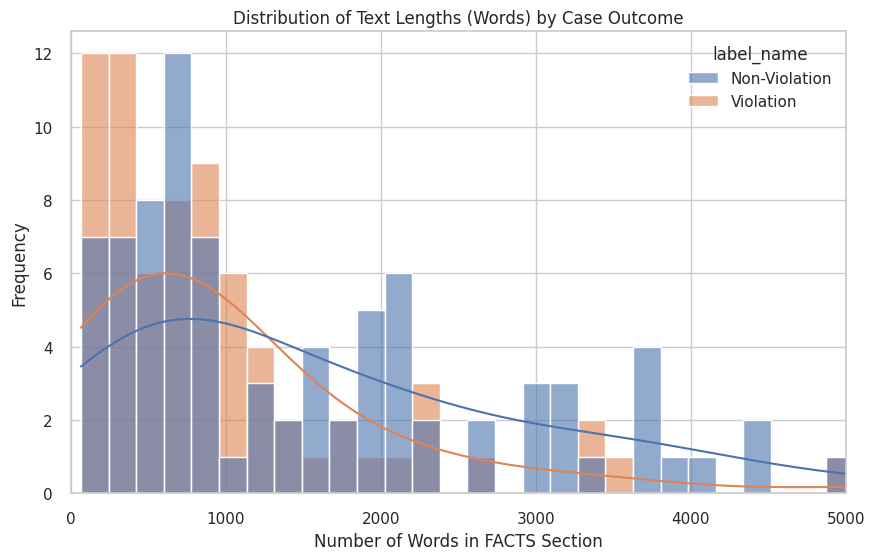

In [5]:
# 1. Distribution of Document Lengths by Class
plt.figure(figsize=(10,6))
sns.histplot(data=df, x='text_length', hue='label_name', bins=50, kde=True, alpha=0.6)
plt.title('Distribution of Text Lengths (Words) by Case Outcome')
plt.xlabel('Number of Words in FACTS Section')
plt.ylabel('Frequency')
plt.xlim(0, 5000) # Cap outliers for better visualization
plt.show()

**Interpretation:** The histogram above shows the text length distribution. If Violation cases generally have longer "FACTS" sections, a model might just learn that "longer text = violation" instead of understanding the legal logic. This is an important bias to track.

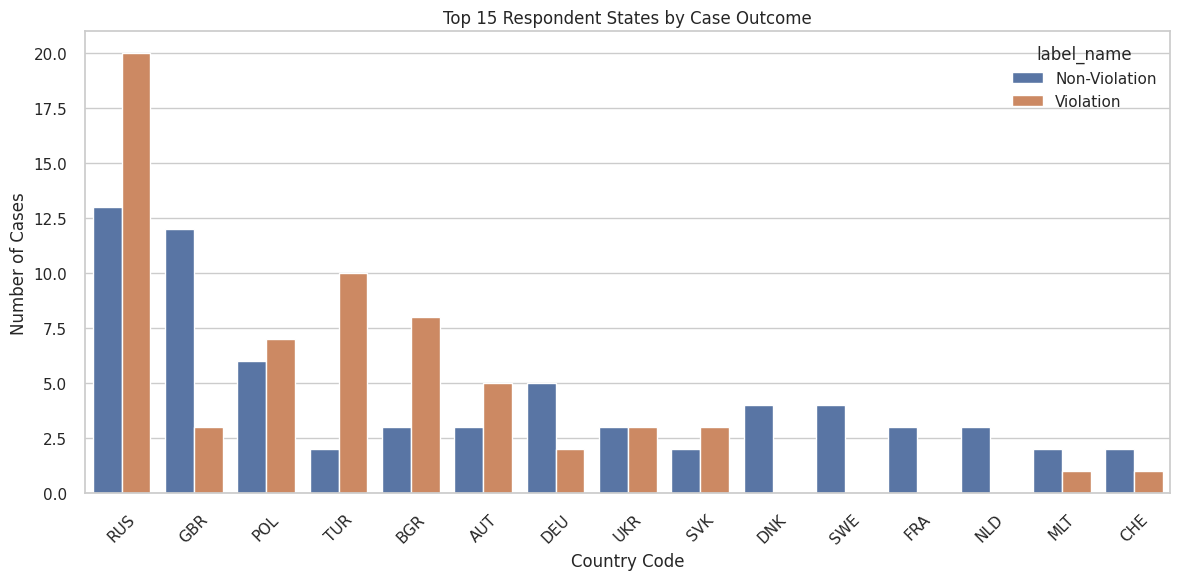

In [6]:
# 2. Respondent State Bias
plt.figure(figsize=(14,6))
top_countries = df['respondent'].value_counts().nlargest(15).index
sns.countplot(data=df[df['respondent'].isin(top_countries)], x='respondent', hue='label_name', order=top_countries)
plt.title('Top 15 Respondent States by Case Outcome')
plt.xlabel('Country Code')
plt.ylabel('Number of Cases')
plt.xticks(rotation=45)
plt.show()

**Interpretation:** This bar chart reveals geographic distribution. We can see if certain countries have overwhelmingly more Violations vs Non-Violations in the dataset. A predictive model could unfairly penalize a specific country simply by seeing its name in the text (e.g., "The applicant, a citizen of RUS..."), which is a critical finding for ethical modelling.

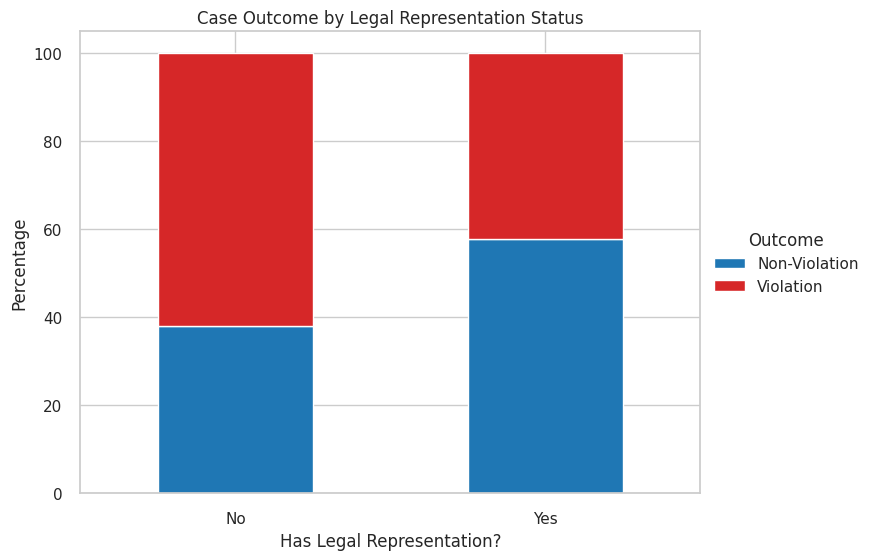

In [7]:
# 3. Does Legal Representation Matter?
representation_outcome = pd.crosstab(df['has_representation'], df['label_name'], normalize='index') * 100

representation_outcome.plot(kind='bar', stacked=True, figsize=(8,6), color=['#1f77b4', '#d62728'])
plt.title('Case Outcome by Legal Representation Status')
plt.xlabel('Has Legal Representation?')
plt.ylabel('Percentage')
plt.xticks([0, 1], ['No', 'Yes'], rotation=0)
plt.legend(title='Outcome', loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

**Interpretation:** The stacked bar chart shows the win/loss percentage based on whether the applicant had representation. This engineered feature uses regex parsing and explores our secondary hypothesis: cases with professional representation might have different outcome probabilities.

## TF-IDF Analysis (Distributional NLP)
To understand what words drive the difference between classes, we use TF-IDF (Term Frequency - Inverse Document Frequency).

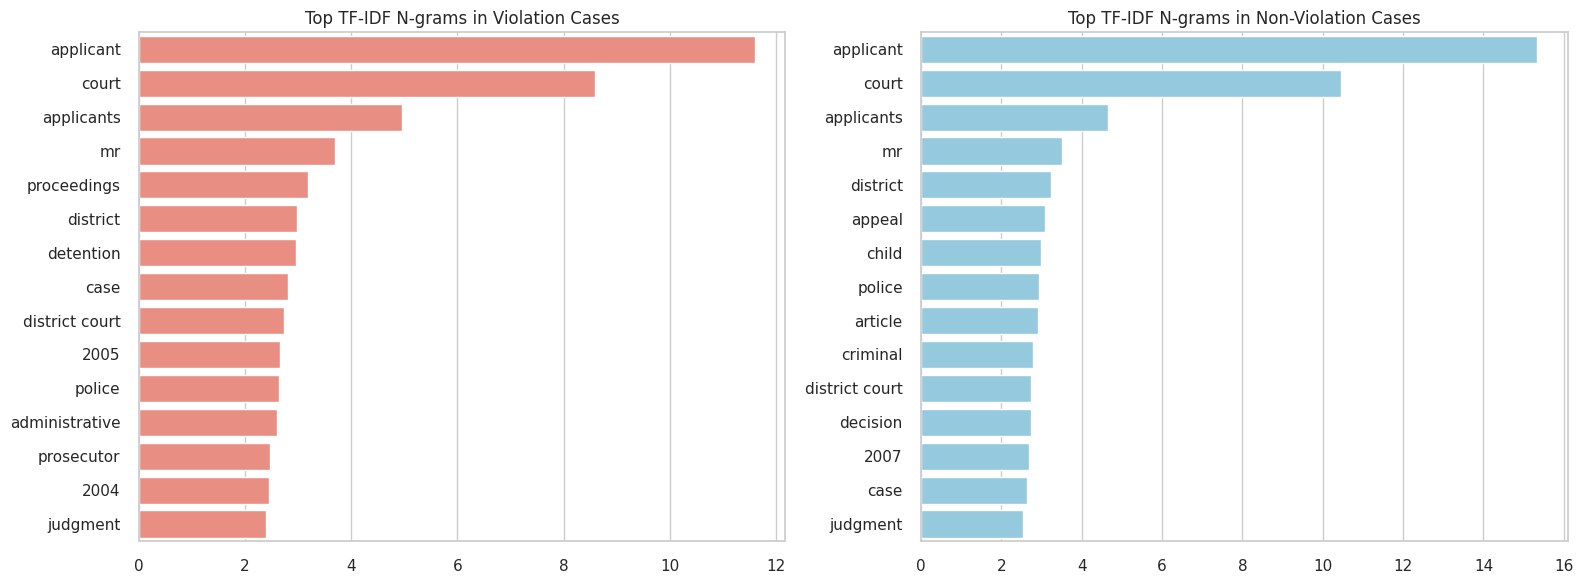

In [8]:
# Extract top words using TF-IDF for each class
def get_top_n_tfidf(texts, n=15):
    vec = TfidfVectorizer(stop_words='english', max_features=1000, ngram_range=(1,2))
    matrix = vec.fit_transform(texts)
    sum_words = matrix.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    return words_freq[:n]

violation_texts = df[df['label'] == 1]['text'].dropna()
non_violation_texts = df[df['label'] == 0]['text'].dropna()

top_v = get_top_n_tfidf(violation_texts)
top_nv = get_top_n_tfidf(non_violation_texts)

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(x=[val for word, val in top_v], y=[word for word, val in top_v], ax=axes[0], color='salmon')
axes[0].set_title('Top TF-IDF N-grams in Violation Cases')

sns.barplot(x=[val for word, val in top_nv], y=[word for word, val in top_nv], ax=axes[1], color='skyblue')
axes[1].set_title('Top TF-IDF N-grams in Non-Violation Cases')

plt.tight_layout()
plt.show()

## 6.1 Simple Word Counts (N-grams)
Before using TF-IDF, let's look at simple, raw counts of unigrams and bigrams using `CountVectorizer`.

In [9]:
def get_top_n_words(texts, n=15, ngram_range=(1,1)):
    vec = CountVectorizer(stop_words='english', ngram_range=ngram_range).fit(texts)
    bag_of_words = vec.transform(texts)
    sum_words = bag_of_words.sum(axis=0) 
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key = lambda x: x[1], reverse=True)
    return words_freq[:n]

print("Top 10 Unigrams (Violation):", get_top_n_words(violation_texts, n=10, ngram_range=(1,1)))
print("Top 10 Bigrams (Violation):", get_top_n_words(violation_texts, n=10, ngram_range=(2,2)))

Top 10 Unigrams (Violation): [('applicant', np.int64(1198)), ('court', np.int64(868)), ('mr', np.int64(392)), ('proceedings', np.int64(277)), ('case', np.int64(239)), ('applicants', np.int64(237)), ('prosecutor', np.int64(228)), ('decision', np.int64(226)), ('district', np.int64(200)), ('police', np.int64(195))]
Top 10 Bigrams (Violation): [('district court', np.int64(149)), ('prosecutor office', np.int64(113)), ('mr bekirski', np.int64(94)), ('regional court', np.int64(83)), ('administrative court', np.int64(65)), ('cm cm', np.int64(65)), ('supreme court', np.int64(63)), ('criminal proceedings', np.int64(61)), ('unspecified date', np.int64(51)), ('case file', np.int64(50))]


## 6.2 Fighting Words (`shifterator`)
To visualize words that most distinguish the two classes, we use the `shifterator` library to plot Jensen-Shannon Divergence Shifts. This creates interpretable horizontal bar charts showing which words are pulling a case towards "Violation" vs "Non-Violation".

/home/leondgarse/virtualenvs/workon312/lib/python3.12/site-packages/shifterator/plotting.py:604: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x_ticks, fontsize=plot_params["xtick_fontsize"])


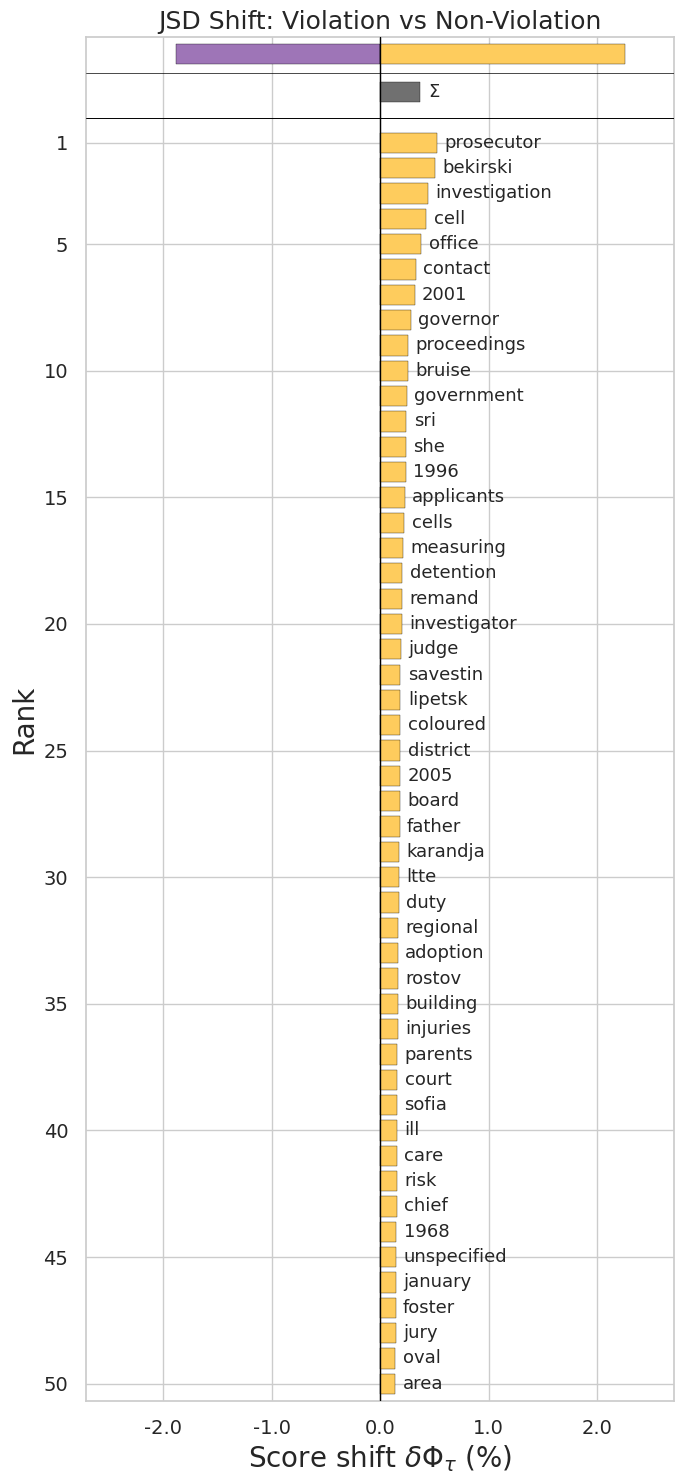

In [10]:
# Clean and count for Shifterator
def get_counts(texts):
    # Simple tokenization for shifterator
    all_text = ' '.join(texts).lower()
    # keeping only words
    words = re.findall(r'\w+', all_text)
    # remove very common stopwords manually for a cleaner shift
    stopwords = set(nltk.corpus.stopwords.words('english')) if 'stopwords' in dir(nltk.corpus) else set(['the', 'a', 'of', 'and', 'to', 'in', 'that', 'was', 'for', 'on', 'is', 'as', 'by', 'it', 'with'])
    words = [w for w in words if w not in stopwords and len(w)>2]
    return dict(Counter(words))

count_v = get_counts(violation_texts)
count_nv = get_counts(non_violation_texts)

# Produce JSD shift
jsd_shift = sh.JSDivergenceShift(type2freq_1=count_nv,
                                 type2freq_2=count_v,
                                 weight_1=0.5,
                                 weight_2=0.5,
                                 reference_value='average')

jsd_shift.get_shift_graph(system_names=['Non-Violation', 'Violation'], title='JSD Shift: Violation vs Non-Violation', cumulative_inset=False, text_size_inset=False)
plt.show()

## 6.3 Scattertext Visualization
Scattertext is a great tool to interactively explore term associations between two categories.

In [11]:
import os
# Create a smaller corpus for scattertext to run quickly
sample_df = df.sample(n=min(1000, len(df)), random_state=42)

corpus = st.CorpusFromPandas(sample_df,
                             category_col='label_name',
                             text_col='text',
                             nlp=st.whitespace_nlp_with_sentences
                            ).build()

html = st.produce_scattertext_explorer(corpus,
                                       category='Violation',
                                       category_name='Violation',
                                       not_category_name='Non-Violation',
                                       width_in_pixels=1000,
                                       metadata=sample_df['respondent'])

with open('scattertext_viz.html', 'w', encoding='utf-8') as f:
    f.write(html)
    
print("Scattertext visualization saved to 'scattertext_viz.html'. Open this file in your browser to interact with it.")

Scattertext visualization saved to 'scattertext_viz.html'. Open this file in your browser to interact with it.


## 6.4 NLTK Concordance Analysis
Concordances let us view specific key terms in the context they appear in the text. Let's look at how the word "violation" or "rights" is used.

In [12]:
# We combine a sample of texts to look at context
sample_text = " ".join(df['text'].dropna().sample(n=50, random_state=42).tolist())
tokens = word_tokenize(sample_text)
nltk_text = Text(tokens)

print("=== Concordance for 'violation' ===")
nltk_text.concordance('violation', lines=5)
print("\n=== Concordance for 'court' ===")
nltk_text.concordance('court', lines=5)

=== Concordance for 'violation' ===
Displaying 4 of 4 matches:
in which he alleged_ inter alia_ a violation of Article 14 of the Convention an
er concluded that the finding of a violation represented in itself sufficient j
the argument concerning an alleged violation of the applicants ' legitimate exp
 the Constitutional Court found no violation of the right to a fair trial and u

=== Concordance for 'court' ===
Displaying 5 of 590 matches:
rectly.37 . On 21 September 2004 the court commissioned a forensic medical expe
17 April 2006 the Sovetskiy District Court of Orel dismissed the applicant 's c
missed the applicant 's claims . The court found that the doctors ' failure to 
revented Mr Korogodin 's death . The court based its findings on the testimonie
 . On 14 June 2006 the Orel Regional Court upheld the judgment of 17 April 2006


## 7. Conclusions and Next Steps
**Conclusion:** 
Through this EDA, we successfully analyzed the ECHR dataset. The textual metrics and TF-IDF visualizations show that vocabulary differences exist between the two classes, suggesting that predicting case outcomes strictly from the "FACTS" section is feasible and a promising machine learning task. 

However, we also identified strong potential confounding variables: text length distributions, specific country bias, and representation status all correlate with outcomes. 

**Next Steps for Modeling:**
1. Train a baseline traditional ML model (e.g., SVM with TF-IDF) and compare it against a Deep Learning approach (Legal-BERT).
2. Apply explainability techniques (like LIME or Integrated Gradients) during evaluation to ensure the models aren't simply predicting based on the biased artifacts (like country names or document length) discovered during this EDA.